# Übung 2

## In dieser Übung ...
... beschäftigen wir uns mit einem einfachen Feedforward-Netz, das ich Ihnen für die Klassifikation von handgeschriebenen Ziffern trainiert habe. Sie werden den Ziffern-Datensatz kennenlernen (Übung 2.1), ein Feedforward-Netz selber (from scratch) implementieren (Übung 2.2) und die Genauigkeit (Accuracy) des Netzes auf den verschiedenen Datensätzen bestimmen (Übung 2.3).

### 2.1 Der MNIST Datensatz

Unter den klassischen Datensätzen der Machine Learning Community ist MNIST einer der bekanntesten. Wenn ein Datensatz einen eigenen [Wikipedia-Eintrag](https://en.wikipedia.org/wiki/MNIST_database) besitzt, wissen Sie, dass er wichtig ist. MNIST steht für *Modified National Institute of Standards and Technology database* und enthält handgeschriebene Ziffern von 0 bis 9, von denen die letzten 10000 als Testset genutzt werden. Die Ziffern wurden von zwei unterschiedlichen Kohorten (nämlich High-School Schüler und Angestellten der US-amerikanischen Volkszählungsbehörde) geschrieben und dann durchmischt, sodass zum Training und Testen genutzten Datensätze keine Verzerrungen aufweisen.

**Ihre Aufgaben**

(1) Importieren Sie die Daten, indem Sie die unten aufgeführte Codezelle ausführen. Falls Sie noch keine Installation von Keras vorliegen haben sollten, können Sie diese mit `pip install keras tensorflow` installieren. Sie benötigen `tensorflow` ([oder ein anderes Backend](https://keras.io/getting_started/#getting-started-with-keras)) als Grundlage für Keras.

In [8]:
%matplotlib inline
import os
os.environ["KERAS_BACKEND"] = "torch"

from keras import datasets
import numpy as np

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()


# rescaling
def rescale_reshape(image):
    temp = ((image / np.max(image)) - .5) * 2
    return temp.reshape((temp.shape[0], temp.shape[1] * temp.shape[2]))


# your data:
# training set: (Xtrain, Ytrain)
# test set: (Xtest, Ytest)
Xtrain = rescale_reshape(train_images)
Ytrain = train_labels
Xtest = rescale_reshape(test_images)
Ytest = test_labels

(2) Untersuchen Sie die importierten Daten: Welche Dimensionen (Shapes) haben die Daten? Schlagen Sie kurz [hier](https://en.wikipedia.org/wiki/MNIST_database) nach: Verfügen Sie über die richtige Anzahl an Trainings- und Testdaten?

In [9]:
Xtrain.shape
Xtest.shape
#wikipedia says: In 2019, the full 60k test set from MNIST was restored to construct the QMNIST, which has 60k images in the training set and 60k in the test set.
#Xtest is only 10000?
#And the images are 28*28= 784 => correct

(10000, 784)

(3) Visualisieren Sie aus dem Trainingsdatensatz Beispiele für ausgewählte Ziffern 0 bis 9. Nutzen Sie dazu die matplotlib-Bibliothek (Methode `imshow`) und vergessen Sie nicht, die Daten vor der Visualisierung in die richtige Form zu bringen (`reshape` hilft Ihnen hier; die richtige Form finden Sie [hier](https://en.wikipedia.org/wiki/MNIST_database)).

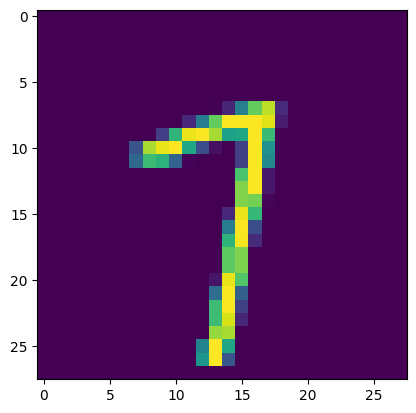

In [10]:
import matplotlib.pyplot as plt

plt.imshow(np.reshape(Xtrain[42], (28, 28)))

### 2.2 Feedforward Netz

Jedes Netz, das Informationen einfach von Vorne (Eingang) zum Ende (Ausgang) transportiert, und dabei keine Schleifen enthält, wird Feedforward-Netz genannt. Der Vorgang selber wird *Forward Propagation* genannt. Sie haben bisher ausschließlich Feedforward-Netze kennengelernt.

Für diese Übung habe ich Ihnen ein kleines neuronales Netz trainiert, das aus den handschriftlichen Ziffern die Zahl vorhersagt. Wir werden in diesem Übungsteil dieses Netz nachbauen und testen. Die Architektur des Netzes ist wie folgt:

1. Schicht ($h_1$): Fully Connected Layer mit 100 Neuronen und Sigmoid Aktivierungsfunktion.
2. Schicht ($h_2$): Fully Connected Layer mit 10 Neuronen und Sigmoid Aktivierungsfunktion.

Die erste Schicht ($h_1$) nimmt einen Vektor der Dimension 784 entgegen. Die Ausgabe der zweiten Schicht ist ein Vektor mit 10 Einträgen. Die Ziffer, die das Netz vorhersagt, entspricht dem Vektorelement, das den maximalen Wert aufweist.

**Ihre Aufgaben**

(1) Führen Sie bitte die folgende Zelle aus, die die Gewichte importiert. Die Benennung der importierten Arrays folgt folgender Konvention: h1 bezeichnet die Gewichte der ersten Schicht; b1 bezeichnet die Bias-Gewichte der ersten Schicht; usw. Untersuchen Sie den shape der importierten Arrays.

In [11]:
from io import BytesIO
import urllib.request
import numpy as np

# import network parameters

file = urllib.request.urlopen('https://data.bialonski.de/ml/network_parameters.npz')
ncontent = np.load(BytesIO(file.read()))
w_h1, b_h1, w_h2, b_h2 = [ncontent[f] for f in ncontent.files]

In [12]:
print(w_h1.shape)
print(b_h1.shape)
print(w_h2.shape)
print(b_h2.shape)

(784, 100)
(100,)
(100, 10)
(10,)


(2) Implementieren Sie eine Funktion mit dem Namen `sigmoid`, die Sie später als Aktivierungsfunktion für Ihre Neuronen verwenden werden. `sigmoid` nimmt einen Wert `z` entgegen und gibt `sigmoid(z)` zurück. Sie finden die Definition dieser Funktion in den Folien der heutigen Vorlesung.

In [13]:
def sigmoid(z):
    return np.exp(z)/(1+np.exp(z))

(3) Implementieren Sie nun die erste Schicht, indem Sie zunächst das Signal s_1 bestimmen (mithilfe der Gewichte w_h1 und b_h1) und dann darauf die Aktivierungsfunktion (sigmoid) anwenden. Das Ergebnis der Aktivierungsfunktion schreiben Sie in `a_h1`. Hinweis: `np.dot` und `np.matmul` werden Ihnen hier hilfreich sein. Beachten Sie die [Unterschiede zwischen den Methoden](https://mkang32.github.io/python/2020/08/30/numpy-matmul.html).

In [23]:
def first_layer(x):
    a_h1 = sigmoid(x@w_h1+b_h1)
    return a_h1

(4) Implementieren Sie auf die gleiche Weise die zweite Schicht, nur nutzen Sie hier die Gewichte w_h2 und b_h2 und nutzen als Eingang für diese Schicht den Inhalt der Variablen `a_h1`. Schreiben Sie das Ergebnis dieser Schicht in die Variable `a_h2`.

In [24]:
def second_layer(x):
    a_h2 = sigmoid(x@w_h2+b_h2)
    return a_h2

(5) Testen Sie Ihr Netz, indem Sie eine beispielhafte Ziffer (z.B. ```Xtrain[0]```) in Ihr Netz geben und sich die Größe der resultierenden Einträge mit dem untenstehenden Befehl visualisieren lassen. Vergleichen Sie mit dem entsprechenden Label. Wird Ihre Ziffer korrekt durch das Netz vorhergesagt?

<BarContainer object of 10 artists>

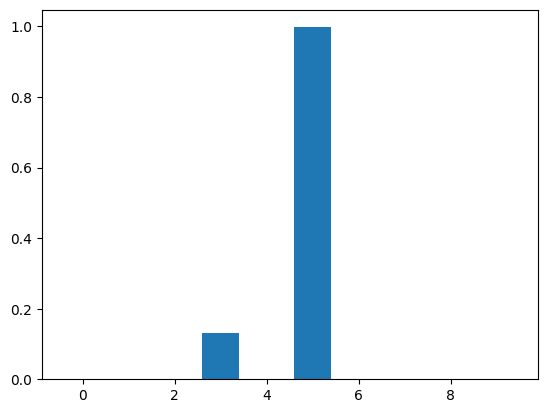

In [21]:
from matplotlib import pyplot as plt

a_h1 = first_layer(Xtrain[0])
a_h2 = second_layer(a_h1)

plt.bar(range(10), a_h2)

#plt.imshow(np.reshape(Xtrain[0], (28, 28)))

### 2.3 Vorhersagegenauigkeit (Accuracy)



In diesem Übungsteil werden Sie ermitteln, welche Vorhersagegenauigkeit das Netz bei der Erkennung handschriftlicher Ziffern erreicht.

Die Genauigkeit (Accuracy) in diesem Klassifikationsproblem sei definiert als die Anzahl der korrekten Vorhersagen dividiert durch alle Vorhersagen auf einem Datensatz.

Als Datensätze betrachten wir das Trainingset und das Testset.

**Ihre Aufgaben**

(1) Schreiben Sie eine Funktion `accuracy`, die die Features (X) sowie die Labels (Y) eines Datensatzes entgegennimmt (z.B. Xtrain, Ytrain) und die Genauigkeit (accuracy) zurückgibt. Dabei kann Ihnen `np.argmax` hilfreich sein.

In [26]:
def accuracy(X, Y):
    A_h1 = first_layer(X)
    A_h2 = second_layer(A_h1)
    y_pred = np.argmax(A_h2, axis=1)
    return np.mean(y_pred == Y)

np.float64(0.9917166666666667)

(2) Bestimmen Sie die accuracy für das Trainingset und für das Testset mithilfe Ihrer Funktion aus Schritt (1).

In [27]:
print(accuracy(Xtrain, Ytrain))
accuracy(Xtest, Ytest)


0.9917166666666667


np.float64(0.9754)

(3) Vergleichen Sie Ihre Genauigkeit mit denen, die Sie [hier](https://en.wikipedia.org/wiki/MNIST_database#Classifiers) dokumentiert finden. Sie können Ihre Genauigkeiten in "Errors" übersetzen mittels: "Error = 1 - accuracy". Auf welchem Rang befindet sich Ihr Netz in dieser Liste?

In [28]:
1-accuracy(Xtest, Ytest) # 5th place?

np.float64(0.024599999999999955)